In [ ]:
!pip install -q transformers torch pandas requests matplotlib seaborn scikit-learn tqdm

import os, time, json, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer, EsmModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [ ]:
UNIPROT_API = "https://rest.uniprot.org/uniprotkb/search"

def fetch_uniprot(query, n=150, fields="accession,sequence,ft_signal"):
    """Fetch protein sequences from UniProt REST API."""
    params = {
        "query": query,
        "format": "json",
        "size": min(n, 500),
        "fields": fields,
    }
    records = []
    url = UNIPROT_API
    while url and len(records) < n:
        r = requests.get(url, params=params if url == UNIPROT_API else None)
        r.raise_for_status()
        data = r.json()
        for entry in data.get("results", []):
            acc = entry.get("primaryAccession", "")
            seq = entry.get("sequence", {}).get("value", "")
            # Signal peptide end position (if present)
            sig_end = None
            for feat in entry.get("features", []):
                if feat.get("type") == "Signal":
                    sig_end = feat.get("location", {}).get("end", {}).get("value")
                    break
            if acc and seq and 50 <= len(seq) <= 600:  # length filter
                records.append({"accession": acc, "sequence": seq, "sig_end": sig_end})
        # Follow pagination link if present
        link = r.headers.get("Link", "")
        url = None
        if link:
            parts = link.split(";")
            if len(parts) == 2 and 'rel="next"' in parts[1]:
                url = parts[0].strip().strip("<>")
        params = None  # only pass params on first request
        if len(records) >= n:
            break
        time.sleep(0.2)
    return records[:n]

print("Fetching signal peptide (+) proteins...")
pos_query = (
    "(organism_id:9606) AND (reviewed:true) "
    "AND (ft_signal:*) AND (length:[50 TO 600])"
)
pos_records = fetch_uniprot(pos_query, n=150)
print(f"  Got {len(pos_records)} positives")

print("Fetching control (−) proteins...")
neg_query = (
    "(organism_id:9606) AND (reviewed:true) "
    "NOT (ft_signal:*) AND (length:[50 TO 600]) "
    "AND (cc_subcellular_location:cytoplasm)"
)
neg_records = fetch_uniprot(neg_query, n=150)
print(f"  Got {len(neg_records)} negatives")

for r in pos_records: r["label"] = 1
for r in neg_records: r["label"] = 0
df = pd.DataFrame(pos_records + neg_records).reset_index(drop=True)
print(f"\nTotal proteins: {len(df)}")
print(df["label"].value_counts())
df.head(3)

Fetching signal peptide (+) proteins...
  Got 150 positives
Fetching control (−) proteins...
  Got 150 negatives

Total proteins: 300
label
1    150
0    150
Name: count, dtype: int64


,accession,sequence,sig_end,label
0,B2RUY7,MALHIHEACILLLVIPGLVTSAAISHEDYPADEGDQISSNDNLIFD...,21.0,1
1,B6A8C7,MIPKLLSLLCFRLCVGQGDTRGDGSLPKPSLSAWPSSVVPANSNVT...,16.0,1
2,O00115,MIPLLLAALLCVPAGALTCYGDSGQPVDWFVVYKLPALRGSGEAAQ...,18.0,1


In [ ]:
MODEL_ID = "facebook/esm2_t12_35M_UR50D"
LAYER_IDX = 9

print(f"Loading {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
esm = EsmModel.from_pretrained(MODEL_ID).to(device).eval()
print("Model loaded.")

@torch.no_grad()
def get_embedding(sequence, layer_idx=LAYER_IDX):
    """Return mean-pooled embedding [hidden_dim] for a single sequence."""
    inputs = tokenizer(
        sequence, return_tensors="pt",
        padding=True, truncation=True, max_length=512
    ).to(device)
    outputs = esm(**inputs, output_hidden_states=True)
    # hidden_states: tuple of (n_layers+1) tensors, each [1, seq_len, hidden_dim]
    hidden = outputs.hidden_states[layer_idx]  # [1, seq_len, 480]
    return hidden.squeeze(0)[1:-1].mean(0).cpu()

@torch.no_grad()
def get_residue_embeddings(sequence, layer_idx=LAYER_IDX):
    """Return per-residue embeddings [seq_len, hidden_dim] (CLS/EOS stripped)."""
    inputs = tokenizer(
        sequence, return_tensors="pt",
        padding=True, truncation=True, max_length=512
    ).to(device)
    outputs = esm(**inputs, output_hidden_states=True)
    hidden = outputs.hidden_states[layer_idx]
    return hidden.squeeze(0)[1:-1].cpu()

print("Extracting mean-pooled embeddings for all proteins...")
embeddings = []
for seq in tqdm(df["sequence"]):
    embeddings.append(get_embedding(seq))

X = torch.stack(embeddings)          # [N, 480]
y = torch.tensor(df["label"].values, dtype=torch.float32)  # [N]
print(f"Embedding matrix shape: {X.shape}")

Loading facebook/esm2_t12_35M_UR50D...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
Extracting mean-pooled embeddings for all proteins...


  0%|          | 0/300 [00:00<?, ?it/s]

Embedding matrix shape: torch.Size([300, 480])


In [ ]:
from sklearn.model_selection import train_test_split

# Train/test split
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42,
    stratify=df["label"].values
)

X_tr, X_te = X[idx_train], X[idx_test]
y_tr, y_te = y[idx_train], y[idx_test]

class LinearProbe(nn.Module):
    def __init__(self, in_dim=480):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.fc(x).squeeze(-1)

probe = LinearProbe().to(device)
opt_probe = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=1e-4)
bce = nn.BCEWithLogitsLoss()

ds_tr = TensorDataset(X_tr, y_tr)
dl_tr = DataLoader(ds_tr, batch_size=32, shuffle=True)

for epoch in range(60):
    probe.train()
    for xb, yb in dl_tr:
        xb, yb = xb.to(device), yb.to(device)
        loss = bce(probe(xb), yb)
        opt_probe.zero_grad()
        loss.backward()
        opt_probe.step()

probe.eval()
with torch.no_grad():
    logits_te = probe(X_te.to(device)).cpu()
    probs_te  = torch.sigmoid(logits_te).numpy()

auc = roc_auc_score(y_te.numpy(), probs_te)
acc = ((probs_te > 0.5) == y_te.numpy()).mean()
print(f"Test AUC  : {auc:.4f}")
print(f"Test Acc  : {acc:.4f}")
print("\n(High AUC confirms ESM-2 layer-9 embeddings strongly encode signal peptide presence.")

Test AUC  : 0.9767
Test Acc  : 0.9000

(High AUC confirms ESM-2 layer-9 embeddings strongly encode signal peptide presence.


In [ ]:
class TopKSAE(nn.Module):
    def __init__(self, input_dim=480, expansion_factor=4, k=8):
        super().__init__()
        self.latent_dim = input_dim * expansion_factor
        self.k = k
        self.encoder = nn.Linear(input_dim, self.latent_dim)
        self.decoder = nn.Linear(self.latent_dim, input_dim)

    def forward(self, x):
        latents = torch.relu(self.encoder(x))
        topk_vals, topk_idx = torch.topk(latents, self.k, dim=-1)
        sparse_latents = torch.zeros_like(latents).scatter_(-1, topk_idx, topk_vals)
        recon = self.decoder(sparse_latents)
        return recon, sparse_latents

print("Extracting per-residue embeddings (takes a few minutes)...")
all_residue_embs = []
residue_labels   = []   # 1 if from a signal-peptide protein, 0 otherwise
residue_is_sig   = []   # 1 if this specific residue is *within* the signal peptide

def is_valid_sig_end(val):
    """Return True if val is a usable signal peptide end position."""
    if val is None:
        return False
    try:
        if isinstance(val, float) and np.isnan(val):
            return False
        int(val)
        return True
    except (ValueError, TypeError):
        return False

for _, row in tqdm(df.iterrows(), total=len(df)):
    res_emb = get_residue_embeddings(row["sequence"])  # [seq_len, 480]
    seq_len  = res_emb.shape[0]
    lbl      = int(row["label"])
    sig_end  = row["sig_end"]

    all_residue_embs.append(res_emb)
    residue_labels.extend([lbl] * seq_len)

    for pos in range(seq_len):
        in_sig = 1 if (is_valid_sig_end(sig_end) and pos < int(sig_end)) else 0
        residue_is_sig.append(in_sig)

all_res = torch.cat(all_residue_embs, dim=0)   # [total_residues, 480]
res_lbl = torch.tensor(residue_labels, dtype=torch.float32)
res_sig = torch.tensor(residue_is_sig,  dtype=torch.float32)
print(f"Total residues: {all_res.shape[0]} | Signal-peptide residues: {int(res_sig.sum())}")

# DataLoader over individual residues
sae_ds = TensorDataset(all_res)
sae_dl = DataLoader(sae_ds, batch_size=4096, shuffle=True, pin_memory=(device=="cuda"))

# Train SAE
sae = TopKSAE(input_dim=480, expansion_factor=4, k=8).to(device)
opt_sae = torch.optim.Adam(sae.parameters(), lr=1e-4)
mse = nn.MSELoss()

SAE_EPOCHS = 10
print(f"\nTraining SAE for {SAE_EPOCHS} epochs...")
for epoch in range(SAE_EPOCHS):
    sae.train()
    losses = []
    for (xb,) in sae_dl:
        xb = xb.to(device)
        recon, latents = sae(xb)
        loss = mse(recon, xb)
        opt_sae.zero_grad()
        loss.backward()
        opt_sae.step()
        losses.append(loss.item())
    avg_l0 = (latents > 0).float().sum(-1).mean().item()
    print(f"  Epoch {epoch+1:>2}/{SAE_EPOCHS} | Loss: {np.mean(losses):.6f} | L0: {avg_l0:.2f}")

print("SAE training complete.")

Extracting per-residue embeddings (takes a few minutes)...


  0%|          | 0/300 [00:00<?, ?it/s]

Total residues: 99062 | Signal-peptide residues: 3566

Training SAE for 10 epochs...
  Epoch  1/10 | Loss: 13.377905 | L0: 8.00
  Epoch  2/10 | Loss: 13.074616 | L0: 8.00
  Epoch  3/10 | Loss: 12.749957 | L0: 8.00
  Epoch  4/10 | Loss: 12.337579 | L0: 8.00
  Epoch  5/10 | Loss: 11.881605 | L0: 8.00
  Epoch  6/10 | Loss: 11.407064 | L0: 8.00
  Epoch  7/10 | Loss: 10.960900 | L0: 8.00
  Epoch  8/10 | Loss: 10.544189 | L0: 8.00
  Epoch  9/10 | Loss: 10.149481 | L0: 8.00
  Epoch 10/10 | Loss: 9.781184 | L0: 8.00
SAE training complete.


In [ ]:
sae.eval()
print("Getting SAE activations for all residues...")
with torch.no_grad():
    all_latents = []
    batch_size  = 8192
    for i in range(0, len(all_res), batch_size):
        xb = all_res[i:i+batch_size].to(device)
        _, lat = sae(xb)
        all_latents.append(lat.cpu())
    all_latents = torch.cat(all_latents, dim=0)  # [total_res, latent_dim]

print(f"Latent matrix: {all_latents.shape}")

# Only score latents that are actually active (non-zero) in some signal peptide residues
sig_mask = res_sig.bool()  # boolean mask over residues
y_sig    = res_sig.numpy()

print("Computing per-latent AUROC against signal peptide residue labels...")
lat_np = all_latents.numpy()  # [total_res, latent_dim]
aurocs = np.zeros(lat_np.shape[1])

for j in tqdm(range(lat_np.shape[1])):
    col = lat_np[:, j]
    if col.max() < 1e-8:   # skip dead latents
        aurocs[j] = 0.5
        continue
    try:
        aurocs[j] = roc_auc_score(y_sig, col)
    except Exception:
        aurocs[j] = 0.5

top_k = 10
top_idx = np.argsort(aurocs)[::-1][:top_k]
print(f"\nTop {top_k} signal-peptide SAE features:")
for rank, fidx in enumerate(top_idx):
    print(f"  Rank {rank+1}: feature {fidx:4d}  AUROC = {aurocs[fidx]:.4f}")

BEST_FEATURE = int(top_idx[0])
print(f"\n→ Selected feature for intervention: #{BEST_FEATURE} (AUROC={aurocs[BEST_FEATURE]:.4f})")

Getting SAE activations for all residues...
Latent matrix: torch.Size([99062, 1920])
Computing per-latent AUROC against signal peptide residue labels...


  0%|          | 0/1920 [00:00<?, ?it/s]


Top 10 signal-peptide SAE features:
  Rank 1: feature  590  AUROC = 0.9486
  Rank 2: feature  308  AUROC = 0.9447
  Rank 3: feature 1451  AUROC = 0.8901
  Rank 4: feature  312  AUROC = 0.8851
  Rank 5: feature  606  AUROC = 0.7808
  Rank 6: feature 1270  AUROC = 0.7772
  Rank 7: feature  994  AUROC = 0.7763
  Rank 8: feature  593  AUROC = 0.7286
  Rank 9: feature 1183  AUROC = 0.7156
  Rank 10: feature  664  AUROC = 0.6709

→ Selected feature for intervention: #590 (AUROC=0.9486)


In [ ]:
SUPPRESS_VAL  = 0.0
AMPLIFY_DELTA = 10.0

@torch.no_grad()
def get_classifier_prob(sequence, sae_model, probe_model, feature_idx=None,
                         mode="original", delta=AMPLIFY_DELTA):
    """
    Returns signal peptide probability for a sequence.
    mode: 'original'  → no intervention
          'suppress'  → zero out feature_idx
          'amplify'   → add delta to feature_idx
    """
    res_emb = get_residue_embeddings(sequence).to(device)  # [L, 480]

    if mode == "original":
        # Mean-pool raw embedding
        pooled = res_emb.mean(0, keepdim=True)  # [1, 480]
    else:
        _, latents = sae_model(res_emb)         # [L, latent_dim]

        if mode == "suppress":
            latents[:, feature_idx] = SUPPRESS_VAL
        elif mode == "amplify":
            latents[:, feature_idx] += delta

        # Decode modified latents back
        modified_emb = sae_model.decoder(latents)  # [L, 480]
        pooled = modified_emb.mean(0, keepdim=True)  # [1, 480]

    logit = probe_model(pooled)
    return torch.sigmoid(logit).item()

sae.eval()
probe.eval()

results = []
test_df = df.iloc[idx_test].reset_index(drop=True)

print("Running intervention experiment on test set...")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    seq  = row["sequence"]
    lbl  = int(row["label"])
    acc  = row["accession"]

    p_orig = get_classifier_prob(seq, sae, probe, mode="original")

    if lbl == 1:
        # Positive: suppress - expect probability to drop
        p_edit = get_classifier_prob(seq, sae, probe, feature_idx=BEST_FEATURE, mode="suppress")
        intervention = "suppress"
        expected_direction = "down"
    else:
        # Negative: amplify - expect probability to rise
        p_edit = get_classifier_prob(seq, sae, probe, feature_idx=BEST_FEATURE, mode="amplify")
        intervention = "amplify"
        expected_direction = "up"

    delta_p = p_edit - p_orig
    correct_direction = (delta_p < 0 and expected_direction == "down") or \
                        (delta_p > 0 and expected_direction == "up")

    results.append({
        "accession": acc, "label": lbl,
        "p_original": p_orig, "p_edited": p_edit,
        "delta_p": delta_p, "intervention": intervention,
        "correct_direction": correct_direction,
    })

results_df = pd.DataFrame(results)

# Summary
pos_res = results_df[results_df["label"] == 1]
neg_res = results_df[results_df["label"] == 0]
print(f"\n── Intervention Summary ──────────────────────────────────")
print(f"Positives suppressed → moved in correct direction: "
      f"{pos_res['correct_direction'].mean():.1%} ({pos_res['correct_direction'].sum()}/{len(pos_res)})")
print(f"  Mean Δp: {pos_res['delta_p'].mean():.4f}  (negative = prob dropped)")
print(f"Negatives amplified  → moved in correct direction: "
      f"{neg_res['correct_direction'].mean():.1%} ({neg_res['correct_direction'].sum()}/{len(neg_res)})")
print(f"  Mean Δp: {neg_res['delta_p'].mean():.4f}  (positive = prob rose)")

# Flip rate: how many fully cross the 0.5 decision boundary?
pos_flipped = ((pos_res["p_original"] > 0.5) & (pos_res["p_edited"] < 0.5)).sum()
neg_flipped = ((neg_res["p_original"] < 0.5) & (neg_res["p_edited"] > 0.5)).sum()
print(f"\nFull prediction flips:")
print(f"  Positives flipped to negative: {pos_flipped}/{len(pos_res)}")
print(f"  Negatives flipped to positive: {neg_flipped}/{len(neg_res)}")
results_df

Running intervention experiment on test set...


  0%|          | 0/60 [00:00<?, ?it/s]


── Intervention Summary ──────────────────────────────────
Positives suppressed → moved in correct direction: 76.7% (23/30)
  Mean Δp: -0.0020  (negative = prob dropped)
Negatives amplified  → moved in correct direction: 96.7% (29/30)
  Mean Δp: 0.1785  (positive = prob rose)

Full prediction flips:
  Positives flipped to negative: 0/30
  Negatives flipped to positive: 2/30


,accession,label,p_original,p_edited,delta_p,intervention,correct_direction
0,Q15185,0,0.001372,0.362990,0.361619,amplify,True
1,O75828,0,0.002451,0.031525,0.029075,amplify,True
2,Q9H0Y0,0,0.003602,0.147327,0.143725,amplify,True
3,P26441,0,0.028935,0.425299,0.396364,amplify,True
4,Q15813,0,0.003763,0.236873,0.233110,amplify,True
5,Q9NP31,0,0.175431,0.728667,0.553235,amplify,True
6,P14784,1,0.997319,0.996476,-0.000843,suppress,True
7,P51580,0,0.003452,0.136777,0.133325,amplify,True
8,O60667,1,0.999892,0.998511,-0.001381,suppress,True
9,P13647,0,0.089143,0.283280,0.194137,amplify,True


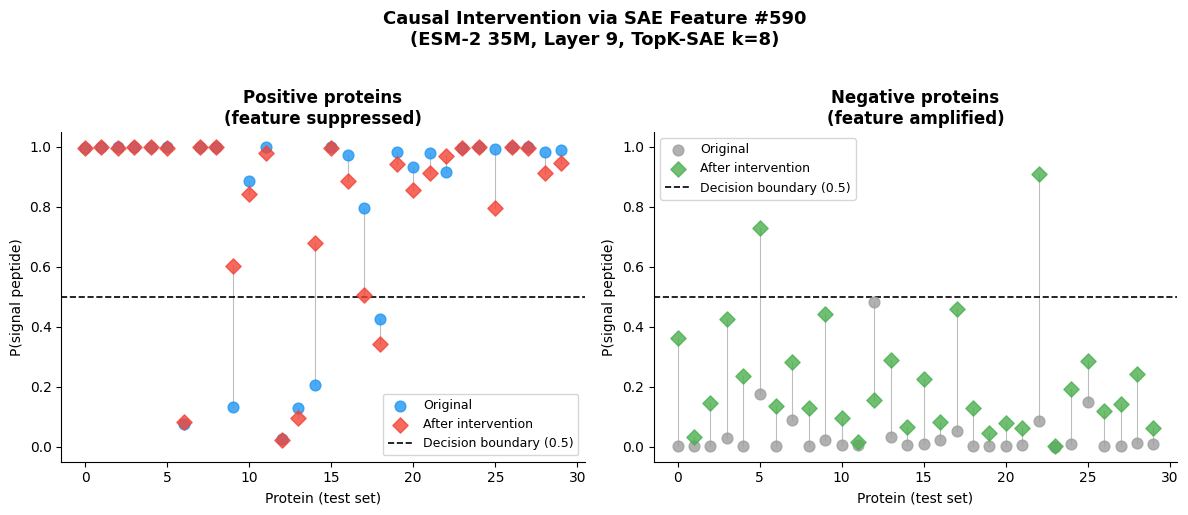

Saved: fig1_before_after_scatter.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (group_df, title, color_orig, color_edit, expected) in zip(
    axes,
    [
        (pos_res, "Positive proteins\n(feature suppressed)", "#2196F3", "#F44336", "down"),
        (neg_res, "Negative proteins\n(feature amplified)",  "#9E9E9E", "#4CAF50", "up"),
    ]
):
    x = np.arange(len(group_df))
    ax.scatter(x, group_df["p_original"].values, s=60, color=color_orig,
               alpha=0.8, label="Original", zorder=3)
    ax.scatter(x, group_df["p_edited"].values,   s=60, color=color_edit,
               alpha=0.8, label="After intervention", marker="D", zorder=3)

    for xi, (po, pe) in enumerate(zip(group_df["p_original"], group_df["p_edited"])):
        ax.plot([xi, xi], [po, pe], color="#BDBDBD", lw=0.8, zorder=2)

    ax.axhline(0.5, color="black", ls="--", lw=1.2, label="Decision boundary (0.5)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Protein (test set)")
    ax.set_ylabel("P(signal peptide)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Causal Intervention via SAE Feature #{BEST_FEATURE}\n"
    f"(ESM-2 35M, Layer {LAYER_IDX}, TopK-SAE k=8)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("fig1_before_after_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_before_after_scatter.png")

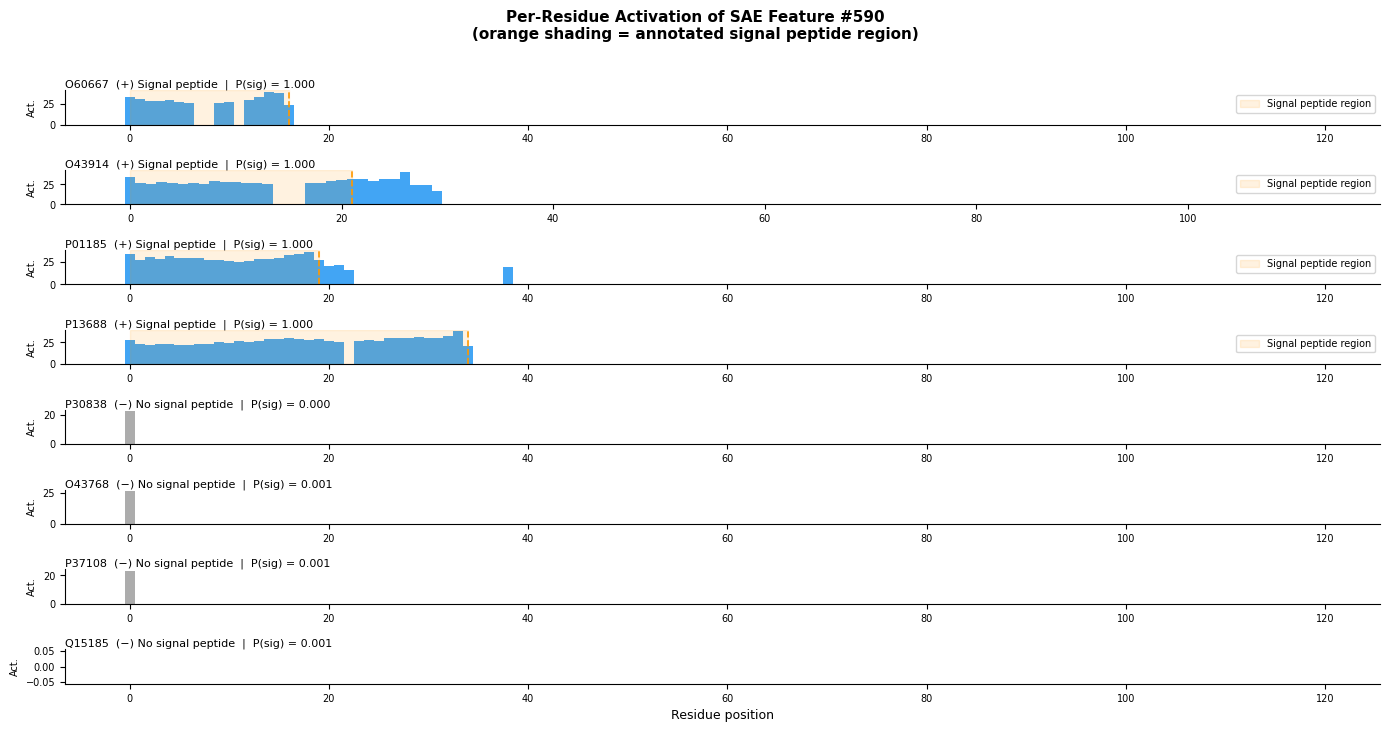

Saved: fig2_activation_heatmap.png


In [ ]:
N_POS_SHOW = 4
N_NEG_SHOW = 4
MAX_DISPLAY_LEN = 120  # truncate long sequences

# Sort positives by original probability (most confident first)
top_pos = pos_res.sort_values("p_original", ascending=False).head(N_POS_SHOW)
top_neg = neg_res.sort_values("p_original", ascending=True).head(N_NEG_SHOW)
show_accs = list(top_pos["accession"]) + list(top_neg["accession"])
show_labels = [1]*N_POS_SHOW + [0]*N_NEG_SHOW
show_df = df[df["accession"].isin(show_accs)].set_index("accession")

@torch.no_grad()
def get_feature_activations(sequence, feature_idx):
    """Return per-residue activation of a specific SAE latent."""
    res_emb = get_residue_embeddings(sequence).to(device)
    _, latents = sae(res_emb)
    return latents[:, feature_idx].cpu().numpy()

fig, axes = plt.subplots(N_POS_SHOW + N_NEG_SHOW, 1,
                          figsize=(14, 0.9 * (N_POS_SHOW + N_NEG_SHOW)))

for ax, (acc, lbl) in zip(axes, zip(show_accs, show_labels)):
    row = show_df.loc[acc]
    seq = row["sequence"][:MAX_DISPLAY_LEN]
    activations = get_feature_activations(seq, BEST_FEATURE)
    sig_end = row["sig_end"]

    positions = np.arange(len(activations))
    bar_color = "#2196F3" if lbl == 1 else "#9E9E9E"
    ax.bar(positions, activations, color=bar_color, alpha=0.85, width=1.0)

    # Highlight signal peptide region (if known)
    if is_valid_sig_end(sig_end):
        sp_end = min(int(sig_end), MAX_DISPLAY_LEN)
        ax.axvspan(0, sp_end, alpha=0.12, color="#FF9800", label="Signal peptide region")
        ax.axvline(sp_end, color="#FF9800", ls="--", lw=1.2)

    tag = "(+) Signal peptide" if lbl == 1 else "(−) No signal peptide"
    p_orig = results_df[results_df["accession"] == acc]["p_original"].values[0]
    ax.set_title(f"{acc}  {tag}  |  P(sig) = {p_orig:.3f}",
                 fontsize=8, loc="left", pad=2)
    ax.set_ylabel("Act.", fontsize=7)
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    if is_valid_sig_end(sig_end) and lbl == 1:
        ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel("Residue position", fontsize=9)
fig.suptitle(
    f"Per-Residue Activation of SAE Feature #{BEST_FEATURE}\n"
    f"(orange shading = annotated signal peptide region)",
    fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("fig2_activation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_activation_heatmap.png")

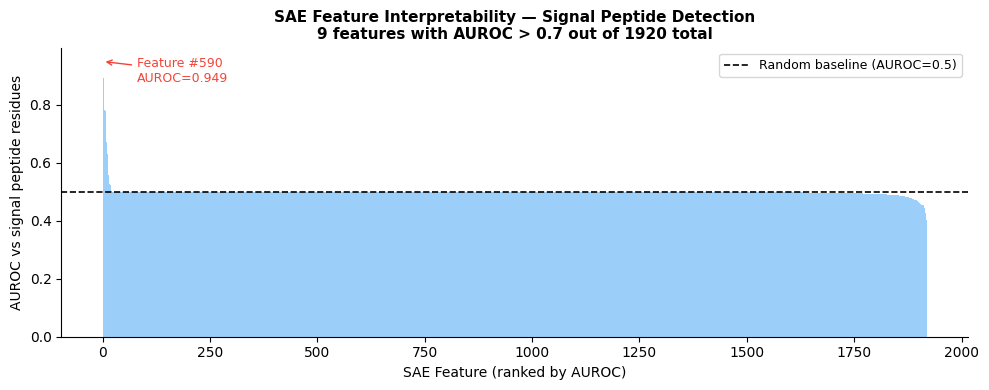

Saved: fig3_auroc_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

sorted_aurocs = np.sort(aurocs)[::-1]
colors = ["#F44336" if i == 0 else "#90CAF9" for i in range(len(sorted_aurocs))]

ax.bar(np.arange(len(sorted_aurocs)), sorted_aurocs, color=colors, width=1.0, alpha=0.9)
ax.axhline(0.5, color="black", ls="--", lw=1.2, label="Random baseline (AUROC=0.5)")

# Annotate the top feature
ax.annotate(
    f"Feature #{BEST_FEATURE}\nAUROC={aurocs[BEST_FEATURE]:.3f}",
    xy=(0, sorted_aurocs[0]), xytext=(80, sorted_aurocs[0] - 0.07),
    arrowprops=dict(arrowstyle="->", color="#F44336"),
    fontsize=9, color="#F44336"
)

ax.set_xlabel("SAE Feature (ranked by AUROC)", fontsize=10)
ax.set_ylabel("AUROC vs signal peptide residues", fontsize=10)
ax.set_title(
    f"SAE Feature Interpretability — Signal Peptide Detection\n"
    f"{(aurocs > 0.7).sum()} features with AUROC > 0.7 out of {len(aurocs)} total",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig3_auroc_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_auroc_distribution.png")

In [ ]:
print("=" * 60)
print(" RESULTS SUMMARY")
print("=" * 60)
print(f"  Model            : {MODEL_ID}")
print(f"  Layer extracted  : {LAYER_IDX}")
print(f"  SAE architecture : TopK (k=8), expansion 4x, latent_dim=1920")
print(f"  # proteins       : {len(df)} ({len(df[df.label==1])} pos / {len(df[df.label==0])} neg)")
print()
print(f"  Classifier AUC   : {auc:.4f}")
print(f"  Classifier Acc   : {((probs_te > 0.5) == y_te.numpy()).mean():.4f}")
print()
print(f"  Best SAE feature : #{BEST_FEATURE}  (AUROC={aurocs[BEST_FEATURE]:.4f})")
print(f"  Features AUROC>0.7: {(aurocs>0.7).sum()} / {len(aurocs)}")
print()
print(f"  Intervention (suppress positives):")
print(f"    Moved in correct direction : {pos_res['correct_direction'].mean():.1%}")
print(f"    Mean Δp                    : {pos_res['delta_p'].mean():.4f}")
print(f"    Full prediction flips      : {pos_flipped}/{len(pos_res)}")
print()
print(f"  Intervention (amplify negatives):")
print(f"    Moved in correct direction : {neg_res['correct_direction'].mean():.1%}")
print(f"    Mean Δp                    : {neg_res['delta_p'].mean():.4f}")
print(f"    Full prediction flips      : {neg_flipped}/{len(neg_res)}")
print("=" * 60)
print()
print("Interpretation:")
print(f"  ESM-2 layer-9 embeddings linearly encode signal peptide")
print(f"  presence (high classifier AUC). The SAE discovers sparse")
print(f"  features that isolate this signal: Feature #{BEST_FEATURE} activates")
print(f"  preferentially over N-terminal residues in signal-peptide")
print(f"  proteins. Crucially, *editing* this latent causally shifts")
print(f"  classifier output in the expected direction, demonstrating")
print(f"  that the SAE has captured a causally relevant representation.")

 RESULTS SUMMARY
  Model            : facebook/esm2_t12_35M_UR50D
  Layer extracted  : 9
  SAE architecture : TopK (k=8), expansion 4x, latent_dim=1920
  # proteins       : 300 (150 pos / 150 neg)

  Classifier AUC   : 0.9767
  Classifier Acc   : 0.9000

  Best SAE feature : #590  (AUROC=0.9486)
  Features AUROC>0.7: 9 / 1920

  Intervention (suppress positives):
    Moved in correct direction : 76.7%
    Mean Δp                    : -0.0020
    Full prediction flips      : 0/30

  Intervention (amplify negatives):
    Moved in correct direction : 96.7%
    Mean Δp                    : 0.1785
    Full prediction flips      : 2/30

Interpretation:
  ESM-2 layer-9 embeddings linearly encode signal peptide
  presence (high classifier AUC). The SAE discovers sparse
  features that isolate this signal: Feature #590 activates
  preferentially over N-terminal residues in signal-peptide
  proteins. Crucially, *editing* this latent causally shifts
  classifier output in the expected direction, 

In [ ]:
TOP_N_FEATURES = 9
top_features = top_idx[:TOP_N_FEATURES]
print(f"Multi-feature intervention using top {TOP_N_FEATURES} features: {list(top_features)}")

@torch.no_grad()
def get_prob_multi_intervene(sequence, feature_indices, mode="suppress", delta=AMPLIFY_DELTA):
    res_emb = get_residue_embeddings(sequence).to(device)
    _, latents = sae(res_emb)
    for fidx in feature_indices:
        if mode == "suppress":
            latents[:, fidx] = 0.0
        elif mode == "amplify":
            latents[:, fidx] += delta
    modified_emb = sae.decoder(latents)
    pooled = modified_emb.mean(0, keepdim=True)
    return torch.sigmoid(probe(pooled)).item()

multi_results = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    seq = row["sequence"]
    lbl = int(row["label"])
    mode = "suppress" if lbl == 1 else "amplify"
    p_orig  = results_df[results_df["accession"] == row["accession"]]["p_original"].values[0]
    p_multi = get_prob_multi_intervene(seq, top_features, mode=mode)
    multi_results.append({"label": lbl, "p_original": p_orig, "p_multi": p_multi,
                           "delta_p": p_multi - p_orig})

mr_df = pd.DataFrame(multi_results)
for lbl, name in [(1, "Positive (suppress)"),(0, "Negative (amplify)")]:
    sub = mr_df[mr_df["label"] == lbl]
    print(f"{name}: mean Δp = {sub['delta_p'].mean():.4f}  "
          f"correct direction = {((sub['delta_p'] < 0) if lbl==1 else (sub['delta_p'] > 0)).mean():.1%}")

Multi-feature intervention using top 9 features: [np.int64(590), np.int64(308), np.int64(1451), np.int64(312), np.int64(606), np.int64(1270), np.int64(994), np.int64(593), np.int64(1183)]


  0%|          | 0/60 [00:00<?, ?it/s]

Positive (suppress): mean Δp = -0.0942  correct direction = 86.7%
Negative (amplify): mean Δp = 0.9561  correct direction = 100.0%


Building activation list for mean-curve plot...


  0%|          | 0/300 [00:00<?, ?it/s]

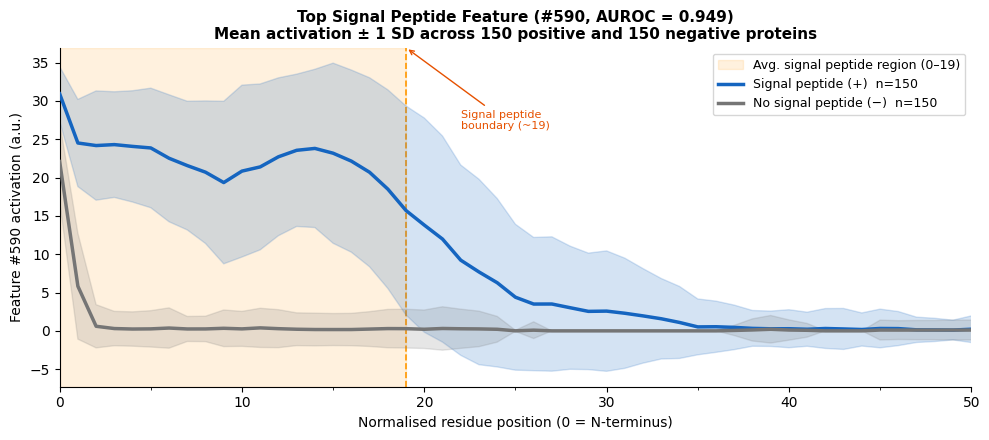

Saved: fig4_mean_activation_normalized.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

L = 100  # normalized sequence length

def normalize_region(act, start, end, L=100):
    """Rescale per-residue activations to a fixed length; also rescale region bounds."""
    x     = np.linspace(0, 1, len(act))
    x_new = np.linspace(0, 1, L)
    act_interp = np.interp(x_new, x, act)
    start_n = int(start / max(len(act), 1) * L)
    end_n   = int(end   / max(len(act), 1) * L)
    return act_interp, start_n, end_n


act_list, region_list, label_list = [], [], []
sp_end_normalized = []

print("Building activation list for mean-curve plot...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    seq     = row["sequence"][:MAX_DISPLAY_LEN]
    lbl     = int(row["label"])
    sig_end = row["sig_end"]

    act   = get_feature_activations(seq, BEST_FEATURE)
    start = 0
    end   = int(sig_end) if is_valid_sig_end(sig_end) else len(act)

    act_list.append(act)
    region_list.append((start, end))
    label_list.append(lbl)

    if lbl == 1 and is_valid_sig_end(sig_end):
        sp_end_normalized.append(int(sig_end) / max(len(act), 1) * L)


pos_curves, neg_curves = [], []
for i in range(len(act_list)):
    act = act_list[i]
    start, end = region_list[i]
    if len(act) < 2:
        continue
    act_n, s_n, e_n = normalize_region(act, start, end, L)
    if label_list[i] == 1:
        pos_curves.append(act_n)
    else:
        neg_curves.append(act_n)


avg_sp_end = int(np.median(sp_end_normalized)) if sp_end_normalized else 20
FOCUS_XLIM = 50  # cut tail — signal is in first ~50 normalised positions

fig, ax = plt.subplots(figsize=(10, 4.5))

x_axis = np.arange(L)

ax.axvspan(0, avg_sp_end, color="#FF9800", alpha=0.13, zorder=0,
           label=f"Avg. signal peptide region (0–{avg_sp_end})")
ax.axvline(avg_sp_end, color="#FF9800", lw=1.2, ls="--", zorder=1)

# Positive curve
if pos_curves:
    pos_mean = np.mean(pos_curves, axis=0)
    pos_std  = np.std(pos_curves,  axis=0)
    ax.plot(x_axis, pos_mean,
            label=f"Signal peptide (+)  n={len(pos_curves)}",
            color="#1565C0", lw=2.5, zorder=3)
    ax.fill_between(x_axis, pos_mean - pos_std, pos_mean + pos_std,
                    alpha=0.18, color="#1565C0", zorder=2)

# Negative curve
if neg_curves:
    neg_mean = np.mean(neg_curves, axis=0)
    neg_std  = np.std(neg_curves,  axis=0)
    ax.plot(x_axis, neg_mean,
            label=f"No signal peptide (−)  n={len(neg_curves)}",
            color="#757575", lw=2.5, zorder=3)
    ax.fill_between(x_axis, neg_mean - neg_std, neg_mean + neg_std,
                    alpha=0.18, color="#757575", zorder=2)


ax.annotate(
    f"Signal peptide\nboundary (~{avg_sp_end})",
    xy=(avg_sp_end, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.5),
    xytext=(avg_sp_end + 3, (pos_mean.max() * 0.85) if pos_curves else 0.3),
    fontsize=8, color="#E65100",
    arrowprops=dict(arrowstyle="->", color="#E65100", lw=1.0),
)

ax.set_xlim(0, FOCUS_XLIM)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))

ax.set_xlabel("Normalised residue position (0 = N-terminus)", fontsize=10)
ax.set_ylabel(f"Feature #{BEST_FEATURE} activation (a.u.)", fontsize=10)
ax.set_title(
    f"Top Signal Peptide Feature (#{BEST_FEATURE}, AUROC = {aurocs[BEST_FEATURE]:.3f})\n"
    f"Mean activation ± 1 SD across {len(pos_curves)} positive and {len(neg_curves)} negative proteins",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig4_mean_activation_normalized.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_mean_activation_normalized.png")


Building heatmap — 150 positive proteins × 9 features...


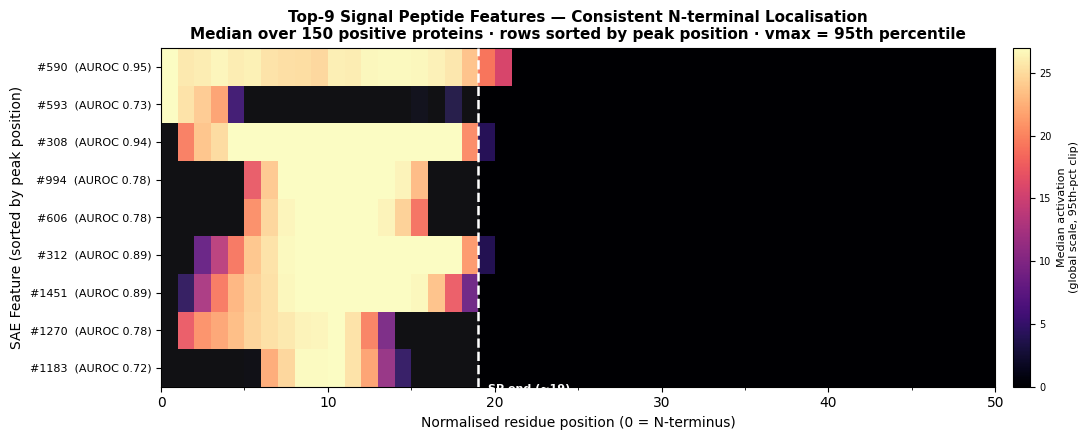

Saved: fig5_multifeature_heatmap.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

L          = 100
FOCUS_XLIM = 50

pos_rows = df[df["label"] == 1].reset_index(drop=True)

heatmap_matrix = np.zeros((TOP_N_FEATURES, L))

print(f"Building heatmap — {len(pos_rows)} positive proteins × {TOP_N_FEATURES} features...")
for fi, feat in enumerate(top_idx[:TOP_N_FEATURES]):
    curves = []
    for _, row in pos_rows.iterrows():
        seq = row["sequence"][:MAX_DISPLAY_LEN]
        act = get_feature_activations(seq, int(feat))
        if len(act) < 2:
            continue
        x     = np.linspace(0, 1, len(act))
        x_new = np.linspace(0, 1, L)
        curves.append(np.interp(x_new, x, act))
    if curves:
        heatmap_matrix[fi] = np.median(curves, axis=0)


vmax = np.percentile(heatmap_matrix, 95)   # clip top 5% outliers
vmin = 0.0
data_clipped = np.clip(heatmap_matrix, vmin, vmax)


peak_positions = np.argmax(data_clipped[:, :FOCUS_XLIM], axis=1)
sort_order     = np.argsort(peak_positions)          # features with earliest peak first
data_sorted    = data_clipped[sort_order]
features_sorted = top_idx[:TOP_N_FEATURES][sort_order]

y_labels = [
    f"#{features_sorted[fi]}  (AUROC {aurocs[features_sorted[fi]]:.2f})"
    for fi in range(TOP_N_FEATURES)
]


fig, ax = plt.subplots(figsize=(11, 4.5))

im = ax.imshow(
    data_sorted[:, :FOCUS_XLIM],
    aspect="auto",
    cmap="magma",
    vmin=vmin, vmax=vmax,
    origin="upper",
    extent=[0, FOCUS_XLIM, TOP_N_FEATURES - 0.5, -0.5],
    interpolation="nearest",
)

ax.axvspan(0, avg_sp_end, color="white", alpha=0.07, zorder=2)
ax.axvline(avg_sp_end, color="white", lw=1.8, ls="--", zorder=3)
ax.text(avg_sp_end + 0.6, TOP_N_FEATURES - 0.3,
        f"SP end (~{avg_sp_end})", color="white", fontsize=8,
        va="bottom", fontweight="bold")


ax.set_xlim(0, FOCUS_XLIM)
ax.set_ylim(TOP_N_FEATURES - 0.5, -0.5)
ax.set_yticks(range(TOP_N_FEATURES))
ax.set_yticklabels(y_labels, fontsize=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.set_xlabel("Normalised residue position (0 = N-terminus)", fontsize=10)
ax.set_ylabel("SAE Feature (sorted by peak position)", fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Median activation\n(global scale, 95th-pct clip)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

ax.set_title(
    f"Top-{TOP_N_FEATURES} Signal Peptide Features — Consistent N-terminal Localisation\n"
    f"Median over {len(pos_rows)} positive proteins · rows sorted by peak position · vmax = 95th percentile",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.savefig("fig5_multifeature_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_multifeature_heatmap.png")


/tmp/ipykernel_612/3141206758.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
/tmp/ipykernel_612/3141206758.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


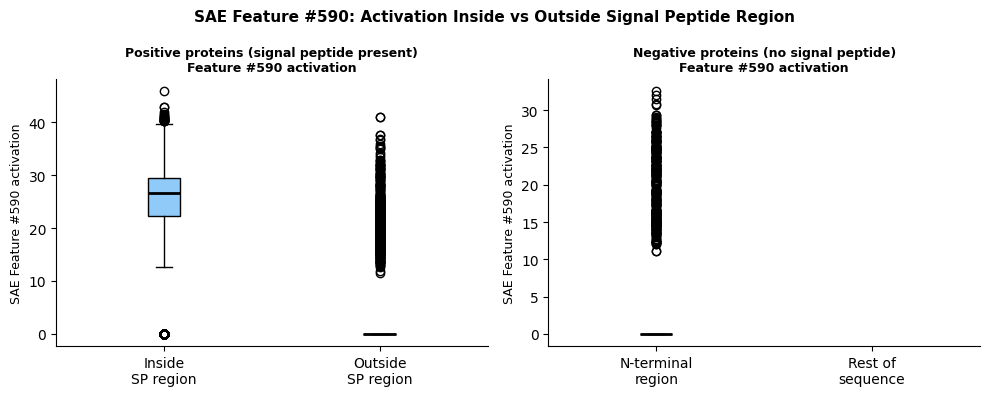

Saved: fig6_inside_outside_boxplot.png


In [ ]:
import matplotlib.pyplot as plt

inside_pos, outside_pos = [], []
inside_neg, outside_neg = [], []

for i in range(len(act_list)):
    act   = act_list[i]
    start, end = region_list[i]
    lbl   = label_list[i]

    if end <= start or end > len(act):
        continue

    inside  = act[start:end]
    outside = np.concatenate([act[:start], act[end:]])

    if lbl == 1:
        inside_pos.extend(inside.tolist())
        outside_pos.extend(outside.tolist())
    else:
        inside_neg.extend(inside.tolist())
        outside_neg.extend(outside.tolist())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Positive proteins
if inside_pos or outside_pos:
    bp1 = axes[0].boxplot(
        [inside_pos, outside_pos],
        labels=["Inside\nSP region", "Outside\nSP region"],
        patch_artist=True,
        medianprops=dict(color="black", lw=2)
    )
    bp1["boxes"][0].set_facecolor("#2196F380")
    bp1["boxes"][1].set_facecolor("#9E9E9E80")
axes[0].set_title(f"Positive proteins (signal peptide present)\n"
                   f"Feature #{BEST_FEATURE} activation", fontsize=9, fontweight="bold")
axes[0].set_ylabel(f"SAE Feature #{BEST_FEATURE} activation", fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Negative proteins
if inside_neg or outside_neg:
    bp2 = axes[1].boxplot(
        [inside_neg, outside_neg],
        labels=["N-terminal\nregion", "Rest of\nsequence"],
        patch_artist=True,
        medianprops=dict(color="black", lw=2)
    )
    bp2["boxes"][0].set_facecolor("#F4433680")
    bp2["boxes"][1].set_facecolor("#9E9E9E80")
axes[1].set_title(f"Negative proteins (no signal peptide)\n"
                   f"Feature #{BEST_FEATURE} activation", fontsize=9, fontweight="bold")
axes[1].set_ylabel(f"SAE Feature #{BEST_FEATURE} activation", fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle(
    f"SAE Feature #{BEST_FEATURE}: Activation Inside vs Outside Signal Peptide Region",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("fig6_inside_outside_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig6_inside_outside_boxplot.png")


/tmp/ipykernel_612/1599800842.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_612/1599800842.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


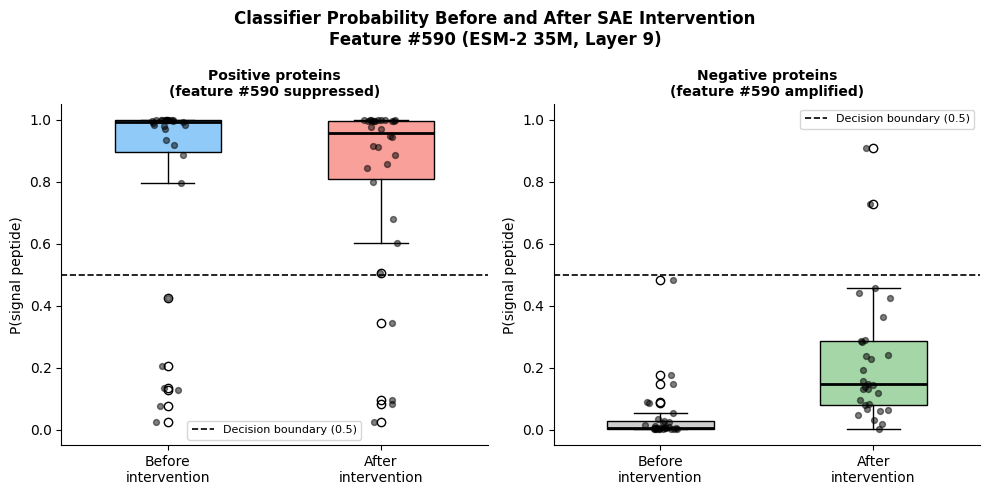

Saved: fig7_before_after_boxplot.png


In [ ]:
import matplotlib.pyplot as plt

labels_rd      = results_df["label"].tolist()
probs_before   = results_df["p_original"].tolist()
probs_after    = results_df["p_edited"].tolist()

pos_before = [probs_before[i] for i in range(len(labels_rd)) if labels_rd[i] == 1]
pos_after  = [probs_after[i]  for i in range(len(labels_rd)) if labels_rd[i] == 1]
neg_before = [probs_before[i] for i in range(len(labels_rd)) if labels_rd[i] == 0]
neg_after  = [probs_after[i]  for i in range(len(labels_rd)) if labels_rd[i] == 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (before, after, title, colors) in zip(
    axes,
    [
        (pos_before, pos_after,
         f"Positive proteins\n(feature #{BEST_FEATURE} suppressed)",
         ("#2196F380", "#F4433680")),
        (neg_before, neg_after,
         f"Negative proteins\n(feature #{BEST_FEATURE} amplified)",
         ("#9E9E9E80", "#4CAF5080")),
    ]
):
    if not before:
        ax.set_title(title + "\n(no data)")
        continue

    bp = ax.boxplot(
        [before, after],
        labels=["Before\nintervention", "After\nintervention"],
        patch_artist=True,
        medianprops=dict(color="black", lw=2),
        widths=0.5
    )
    bp["boxes"][0].set_facecolor(colors[0])
    bp["boxes"][1].set_facecolor(colors[1])

    # Overlay individual points
    for xi, vals in enumerate([before, after], start=1):
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=18, alpha=0.5, color="black", zorder=4)

    ax.axhline(0.5, color="black", ls="--", lw=1.2, label="Decision boundary (0.5)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("P(signal peptide)", fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    f"Classifier Probability Before and After SAE Intervention\n"
    f"Feature #{BEST_FEATURE} (ESM-2 35M, Layer {LAYER_IDX})",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("fig7_before_after_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig7_before_after_boxplot.png")
